In [7]:
from google.colab import files

uploaded = files.upload()


Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [8]:
import pandas as pd

df = pd.read_csv('train.csv')

print(df.shape)
df.head()

(581, 24)


,ID,W,G,R,AB,H,1B,2B,3B,HR,...,HBP,BBHBP,SF,Outs,Outsinplay,RA,BA,OBA,SLG,OPS
0,1,60,162,558,5336,1280,891,247,31,111,...,0,460,0,4056,3216,740,0.239880,0.300207,0.360195,0.660402
1,3,86,161,677,5620,1492,1147,216,46,83,...,0,531,0,4128,3376,643,0.265480,0.328890,0.364591,0.693480
2,5,79,162,679,5550,1496,1088,262,63,83,...,0,543,0,4054,3175,710,0.269550,0.334646,0.384324,0.718971
3,7,96,162,780,5536,1458,990,265,40,163,...,0,561,0,4078,3145,682,0.263367,0.331146,0.414017,0.745164
4,9,96,162,688,5441,1354,905,247,21,181,...,55,597,35,4087,2703,548,0.248851,0.321258,0.401764,0.723022


In [10]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall()

In [11]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()

,ID,W,G,R,AB,H,1B,2B,3B,HR,...,HBP,BBHBP,SF,Outs,Outsinplay,RA,BA,OBA,SLG,OPS
0,1,60,162,558,5336,1280,891,247,31,111,...,0,460,0,4056,3216,740,0.239880,0.300207,0.360195,0.660402
1,3,86,161,677,5620,1492,1147,216,46,83,...,0,531,0,4128,3376,643,0.265480,0.328890,0.364591,0.693480
2,5,79,162,679,5550,1496,1088,262,63,83,...,0,543,0,4054,3175,710,0.269550,0.334646,0.384324,0.718971
3,7,96,162,780,5536,1458,990,265,40,163,...,0,561,0,4078,3145,682,0.263367,0.331146,0.414017,0.745164
4,9,96,162,688,5441,1354,905,247,21,181,...,55,597,35,4087,2703,548,0.248851,0.321258,0.401764,0.723022


In [12]:
import zipfile

with zipfile.ZipFile('house-prices-advanced-regression-techniques.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [13]:
import os

for file in os.listdir():
    print(file)

.config
test.csv
house-prices-advanced-regression-techniques.zip
sample_submission.csv
data_description.txt
archive (1).zip
train.csv
archive.zip
sample_data


In [14]:
df = pd.read_csv('train.csv')

print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [15]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 3)
(292, 3)


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [18]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004]


In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 35788.061292436294
MSE = 2806426667.247853
RMSE = 52975.71771338122
R2 Score = 0.6341189942328371


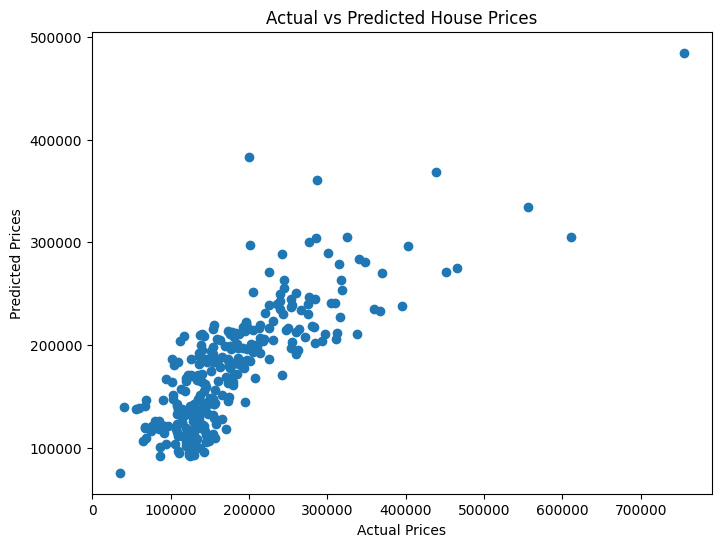

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 35788.061292436294
MSE = 2806426667.247853
RMSE = 52975.71771338122
R2 Score = 0.6341189942328371
